<!-- Cell 1 -->
# 04 — YOLOv11 Training

Trains a YOLOv11 variant on the unified dataset (notebook 02, health-checked in 03). Default is `yolo11s` — a good balance for an 800-image dataset.

| Variant   | Params | Speed   | When to pick |
|-----------|-------:|---------|--------------|
| `yolo11n` | ~2.6 M | fastest | edge / demo |
| `yolo11s` | ~9.4 M | fast    | **default** |
| `yolo11m` | ~20 M  | moderate| if accuracy plateaus |

In [1]:
# Cell 2
# Install dependencies — training framework + plotting
%pip install -q "ultralytics==8.3.*" pandas matplotlib
print("nb04 base dependencies ready")

Note: you may need to restart the kernel to use updated packages.
nb04 base dependencies ready


In [2]:
import torch; print(torch.__version__, torch.cuda.is_available())

2.11.0+cu126 True


In [ ]:
# Cell 3
# Reinstall PyTorch with the right GPU build for this machine:
#   • NVIDIA GPU (Linux/Windows, RTX/GTX) → CUDA cu126 wheel
#       (force-reinstall ensures the CUDA build wins over the +cpu wheel
#        ultralytics may have pulled in above)
#   • Apple Silicon (M1/M2/M3/M4 Mac)     → default PyPI wheel
#       (already ships with MPS / Metal GPU support — no custom index needed)
#   • Anything else                       → default wheel (CPU only)
import platform, subprocess, sys

base = [sys.executable, '-m', 'pip', 'install', '-q', '--force-reinstall',
        'torch', 'torchvision', 'torchaudio']

if sys.platform == 'darwin' and platform.machine() == 'arm64':
    print('Installing PyTorch for Apple Silicon (MPS backend)...')
    cmd = base
elif sys.platform in ('linux', 'win32'):
    print('Installing PyTorch with CUDA (cu126) — compatible with CUDA driver 12.x/13.x...')
    cmd = base + ['--index-url', 'https://download.pytorch.org/whl/cu126']
else:
    print(f'Installing PyTorch (CPU-only fallback for {sys.platform})...')
    cmd = base

subprocess.run(cmd, check=True)
print("nb04 PyTorch ready — restart kernel before running further cells")

<!-- Cell 4 -->
## Imports

In [3]:
# Cell 5
%matplotlib inline

import datetime
import re
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from ultralytics import YOLO

In [ ]:
# Cell 6
DATA_YAML         = Path('../data/dataset/data.yaml').resolve()
MODEL_OUTPUTS_DIR = Path('../model_outputs').resolve()
WEIGHTS_DIR       = Path('../weights')   # backward-compat copy of best.pt

# ── Generate timestamped run folder name ─────────────────────────────────────
# Format: 01_training_batch_2_00am_23_04_2026
MODEL_OUTPUTS_DIR.mkdir(exist_ok=True)
_now  = datetime.datetime.now()
_h12  = _now.strftime('%I').lstrip('0') or '0'   # '02' → '2', midnight → '12'
_min  = _now.strftime('%M')
_ampm = _now.strftime('%p').lower()               # 'am' or 'pm'
_date = _now.strftime('%d_%m_%Y')
_nums = [
    int(m.group(1))
    for d in MODEL_OUTPUTS_DIR.iterdir() if d.is_dir()
    for m in [re.match(r'^(\d+)_', d.name)] if m
]
_next = (max(_nums) + 1) if _nums else 1
RUN_NAME = f"{_next:02d}_training_batch_{_h12}_{_min}{_ampm}_{_date}"
RUN_DIR  = MODEL_OUTPUTS_DIR / RUN_NAME

# ── Accelerator ───────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE      = 0
    DEVICE_NAME = torch.cuda.get_device_name(0)
elif torch.backends.mps.is_available():
    DEVICE      = 'mps'
    DEVICE_NAME = 'Apple Silicon GPU (MPS)'
else:
    DEVICE      = 'cpu'
    DEVICE_NAME = 'CPU (no GPU detected — training will be very slow)'

# ── Training config ───────────────────────────────────────────────────────────
# Change `model` to compare yolo11n / yolo11s / yolo11m
CFG = dict(
    model='yolo11n.pt',
    data=str(DATA_YAML),
    epochs=100,
    imgsz=640,
    batch=16,
    optimizer='SGD',
    lr0=0.01,
    patience=15,
    device=DEVICE,
    project=str(RUN_DIR / 'runs' / 'detect'),
    name='campus_yolo11s',
    seed=42,
)

assert DATA_YAML.exists(), f'missing {DATA_YAML} — run notebook 02 first'
WEIGHTS_DIR.mkdir(exist_ok=True)
print('Device  :', DEVICE, f'({DEVICE_NAME})')
print('Run dir :', RUN_DIR)
CFG

<!-- Cell 7 -->
# Train YOLOv11 with the configured hyperparameters

In [5]:
# Cell 10

import time

model = YOLO(str(CFG['model']))

_t0 = time.time()
results = model.train(**{k: v for k, v in CFG.items() if k != 'model'})
_elapsed = time.time() - _t0

assert results is not None
run_dir = Path(results.save_dir)
_m = int(_elapsed) // 60
print('run dir:', run_dir)
print(f'Training time: {_m // 60:02d}:{_m % 60:02d}')

New https://pypi.org/project/ultralytics/8.4.41 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.253  Python-3.13.12 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\mitah\github_projects\ai_cv_project\data\dataset\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale

<!-- Cell 9 -->
## 2. Training curves
Loss + validation mAP per epoch from `results.csv`.

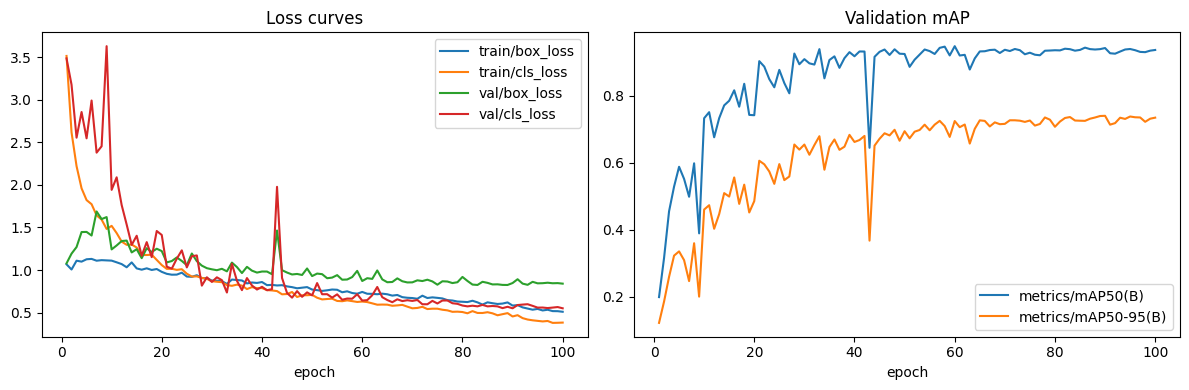

In [6]:
# Cell 10
# Plot loss + mAP curves from results.csv
df = pd.read_csv(run_dir / 'results.csv')
df.columns = [c.strip() for c in df.columns]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df.plot(x='epoch', y=['train/box_loss', 'train/cls_loss', 'val/box_loss', 'val/cls_loss'], ax=ax[0])
ax[0].set_title('Loss curves')
df.plot(x='epoch', y=['metrics/mAP50(B)', 'metrics/mAP50-95(B)'], ax=ax[1])
ax[1].set_title('Validation mAP')
plt.tight_layout(); plt.show()

<!-- Cell 11 -->
## 3. Promote best checkpoint
Copy `best.pt` from the run directory to `weights/best.pt` for downstream notebooks.

In [ ]:
# Cell 12
# Copy best.pt → <run_batch>/weights/best.pt  (canonical per-batch location)
#               → weights/best.pt              (project-level shortcut for downstream notebooks)
best = run_dir / 'weights' / 'best.pt'

batch_weights = RUN_DIR / 'weights'
batch_weights.mkdir(exist_ok=True)
shutil.copy2(best, batch_weights / 'best.pt')
print('saved', batch_weights / 'best.pt')

dst = WEIGHTS_DIR / 'best.pt'
shutil.copy2(best, dst)
print('saved', dst)

<!-- Cell 13 -->
## 4. Quick sanity inference

In [8]:
# Cell 14
# Predict on a few test images, save annotated outputs under <run_dir>/sanity/
test_imgs = list((Path('../data/dataset/images/test')).glob('*.jpg'))[:4]
m = YOLO(dst)
res = m.predict(source=[str(p) for p in test_imgs], imgsz=CFG['imgsz'], conf=0.25,
                save=True, project=str(run_dir), name='sanity')
print('predictions saved under', run_dir / 'sanity')


0: 640x640 1 projector, 16.9ms
1: 640x640 2 projectors, 16.9ms
2: 640x640 1 projector, 16.9ms
3: 640x640 1 projector, 16.9ms
Speed: 2.3ms preprocess, 16.9ms inference, 3.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\mitah\github_projects\ai_cv_project\model_outputs\04_training_batch_1_48am_24_04_2026\sanity
predictions saved under C:\Users\mitah\github_projects\ai_cv_project\model_outputs\04_training_batch_1_48am_24_04_2026\sanity


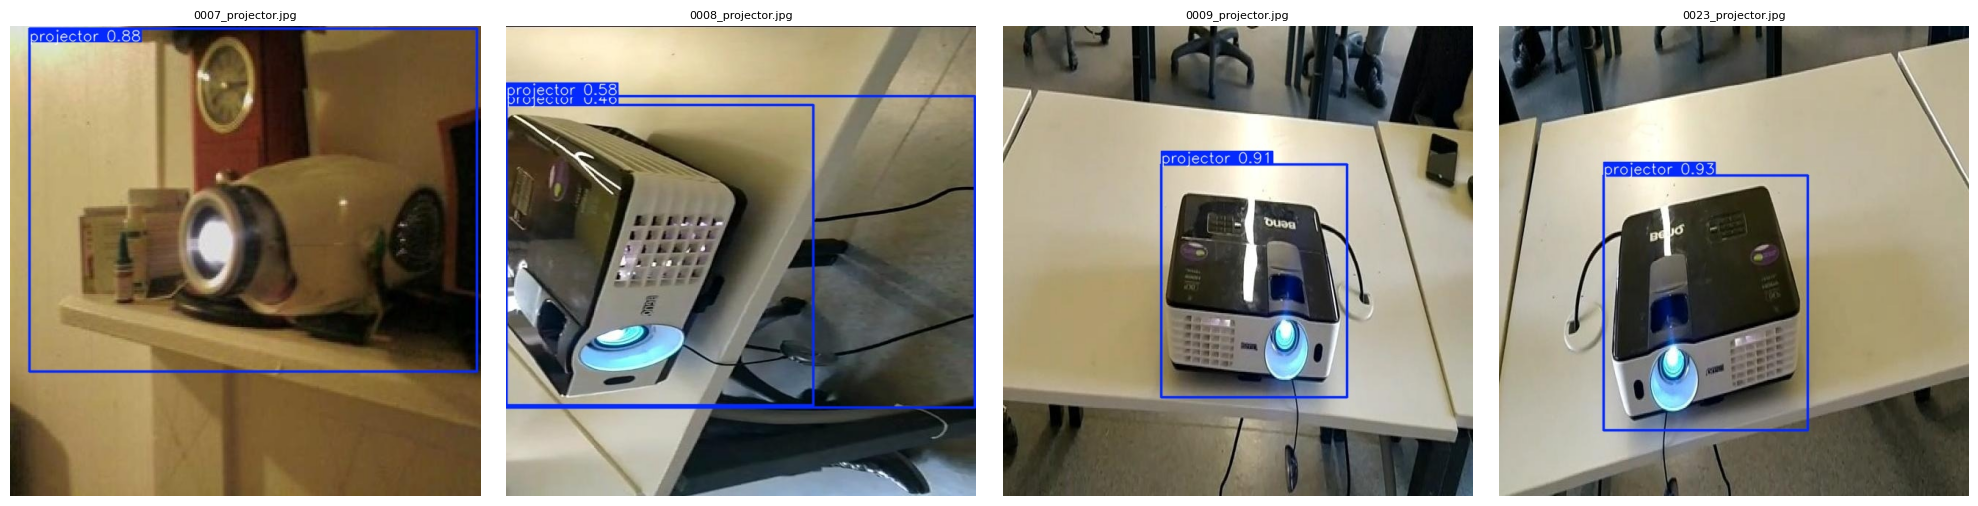

In [9]:
# Cell 15
# Display annotated sanity-inference images inline
from PIL import Image

sanity_dir = run_dir / 'sanity'
saved_imgs = sorted(sanity_dir.glob('*.jpg'))

fig, axes = plt.subplots(1, len(saved_imgs), figsize=(5 * len(saved_imgs), 5))
if len(saved_imgs) == 1:
    axes = [axes]
for ax, img_path in zip(axes, saved_imgs):
    ax.imshow(Image.open(img_path))
    ax.set_title(img_path.name, fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

<!-- Cell 16 -->
### Expected training indicators
- `val/box_loss` decreases smoothly and plateaus
- `mAP@0.5` > 0.80 on val for all 4 classes within ~60–80 epochs
- No runaway gap between train and val loss

Proceed to **notebook 05** for full evaluation.